# CNN-Based Traffic Sign Classification

## Design and Implementation of a Convolutional Neural Network for Traffic Sign Classification

### 1. Introduction

Traffic signs play an important role in road safety and intelligent transportation systems. Automatic recognition of traffic signs is an important computer vision problem and can be used in applications such as Advanced Driver Assistance Systems (ADAS) and autonomous vehicles.

In this project, a Convolutional Neural Network (CNN) is designed and implemented to classify traffic sign images into their respective categories.

The German Traffic Sign Recognition Benchmark (GTSRB) is used for this task. It is a multi-class, single-image classification dataset containing 43 traffic sign categories.

### 2. Objective

The objectives of this project are:

1. To understand and preprocess a real-world image classification dataset.
2. To perform exploratory data analysis on traffic sign images.
3. To design a Convolutional Neural Network for traffic sign classification.
4. To train the CNN using training images.
5. To evaluate the model using accuracy, loss, precision, recall and F1-score.
6. To visualize the confusion matrix.
7. To analyze incorrectly classified images.
8. To test the trained CNN on individual traffic sign images.

### 3. Technologies Used

- Python
- Jupyter Notebook
- TensorFlow / Keras
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- PIL

### 4. Problem Statement

Given an image containing a traffic sign, the CNN should automatically identify the corresponding traffic sign category.

**Image → CNN → Feature Extraction → Classification → Traffic Sign Class**

GPU Verification

In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

print("Available GPUs:", gpus)

if gpus:
    print("GPU is available for CNN training!")
    for gpu in gpus:
        print(gpu)
else:
    print("WARNING: GPU not detected.")

I0000 00:00:1789110345.440960    1366 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789110343.380866    1366 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789110345.587195    1366 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is available for CNN training!
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Then enable memory growth

In [2]:
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("GPU memory growth enabled.")

GPU memory growth enabled.


### Import Libraries

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("Libraries imported successfully.")

Libraries imported successfully.


### Dataset Path

In [4]:
dataset_path = "/home/rohan/projects/traffic-sign-cnn/data/Train"

In [5]:
print(os.path.exists(dataset_path))

True


In [6]:
print(os.listdir(dataset_path)[:10])

['24', '28', '9', '5', '32', '8', '2', '1', '40', '37']


In [7]:
print("Exists:", os.path.exists(dataset_path))
print("First folders:", os.listdir(dataset_path)[:10])
print("Number of classes:", len(os.listdir(dataset_path)))

Exists: True
First folders: ['24', '28', '9', '5', '32', '8', '2', '1', '40', '37']
Number of classes: 43


## Load Data

## Image Loading and Preprocessing

The original GTSRB images have different dimensions. To provide a consistent input size to the CNN, all images are resized to 32 × 32 pixels.

In [8]:
folders = sorted(
    [
        f for f in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, f))
    ]
)

print("Number of folders:", len(folders))
print("Folder names:")
print(folders)

Number of folders: 43
Folder names:
['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']


Load images from all 43 classes

In [9]:
# Reset lists in case the previous cell added anything
IMG_SIZE = 32
images = []
labels = []

for class_id in range(43):

    # Your dataset folders are 0, 1, 2, ..., 42
    class_path = os.path.join(
        dataset_path,
        str(class_id)
    )

    if not os.path.exists(class_path):
        print("Missing class folder:", class_path)
        continue

    for image_name in os.listdir(class_path):

        # Ignore Windows metadata and other non-image files
        if not image_name.lower().endswith((".png", ".jpg", ".jpeg")):
            continue

        image_path = os.path.join(
            class_path,
            image_name
        )

        try:
            image = Image.open(image_path).convert("RGB")
            image = image.resize((IMG_SIZE, IMG_SIZE))

            images.append(np.array(image))
            labels.append(class_id)

        except Exception as e:
            print("Error:", image_path, e)

print("Image loading completed.")
print("Total images loaded:", len(images))
print("Total labels loaded:", len(labels))

Image loading completed.
Total images loaded: 39209
Total labels loaded: 39209


Convert to NumPy arrays

In [10]:
X = np.array(images)
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (39209, 32, 32, 3)
y shape: (39209,)


- Note: Verify the data labels & Unqiue ness

In [11]:
print("Minimum label:", y.min())
print("Maximum label:", y.max())
print("Number of classes:", len(np.unique(y)))

Minimum label: 0
Maximum label: 42
Number of classes: 43


Verify the images

In [12]:
print("Image shape:", X.shape)
print("Data type:", X.dtype)
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Image shape: (39209, 32, 32, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


## Data Labeling

### Class Names

In [13]:
class_names = {
    0: "Speed limit 20 km/h",
    1: "Speed limit 30 km/h",
    2: "Speed limit 50 km/h",
    3: "Speed limit 60 km/h",
    4: "Speed limit 70 km/h",
    5: "Speed limit 80 km/h",
    6: "End of speed limit 80 km/h",
    7: "Speed limit 100 km/h",
    8: "Speed limit 120 km/h",
    9: "No passing",
    10: "No passing for vehicles over 3.5 tons",
    11: "Right-of-way at next intersection",
    12: "Priority road",
    13: "Yield",
    14: "Stop",
    15: "No vehicles",
    16: "Vehicles over 3.5 tons prohibited",
    17: "No entry",
    18: "General caution",
    19: "Dangerous curve left",
    20: "Dangerous curve right",
    21: "Double curve",
    22: "Bumpy road",
    23: "Slippery road",
    24: "Road narrows on the right",
    25: "Road work",
    26: "Traffic signals",
    27: "Pedestrians",
    28: "Children crossing",
    29: "Bicycles crossing",
    30: "Beware of ice/snow",
    31: "Wild animals crossing",
    32: "End of all speed and passing limits",
    33: "Turn right ahead",
    34: "Turn left ahead",
    35: "Ahead only",
    36: "Go straight or right",
    37: "Go straight or left",
    38: "Keep right",
    39: "Keep left",
    40: "Roundabout mandatory",
    41: "End of no passing",
    42: "End of no passing by vehicles over 3.5 tons"
}

print("Number of class names:", len(class_names))

Number of class names: 43


## Class Distribution

In [14]:
unique, counts = np.unique(y, return_counts=True)

class_distribution = pd.DataFrame({
    "Class ID": unique,
    "Class Name": [class_names[i] for i in unique],
    "Number of Images": counts
})

class_distribution

,Class ID,Class Name,Number of Images
0,0,Speed limit 20 km/h,210
1,1,Speed limit 30 km/h,2220
2,2,Speed limit 50 km/h,2250
3,3,Speed limit 60 km/h,1410
4,4,Speed limit 70 km/h,1980
5,5,Speed limit 80 km/h,1860
6,6,End of speed limit 80 km/h,420
7,7,Speed limit 100 km/h,1440
8,8,Speed limit 120 km/h,1410
9,9,No passing,1470


## Plot the distribution

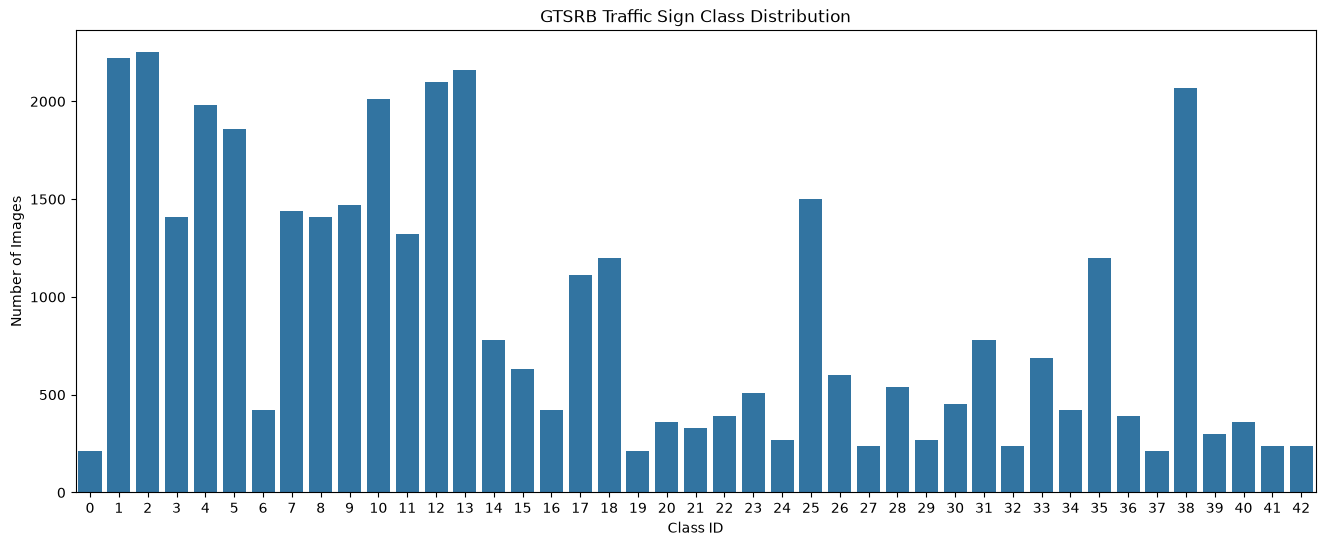

In [15]:
plt.figure(figsize=(16, 6))

sns.barplot(
    data=class_distribution,
    x="Class ID",
    y="Number of Images"
)

plt.title("GTSRB Traffic Sign Class Distribution")
plt.xlabel("Class ID")
plt.ylabel("Number of Images")

plt.show()

## Visualize Sample Images

Display 16 random traffic signs

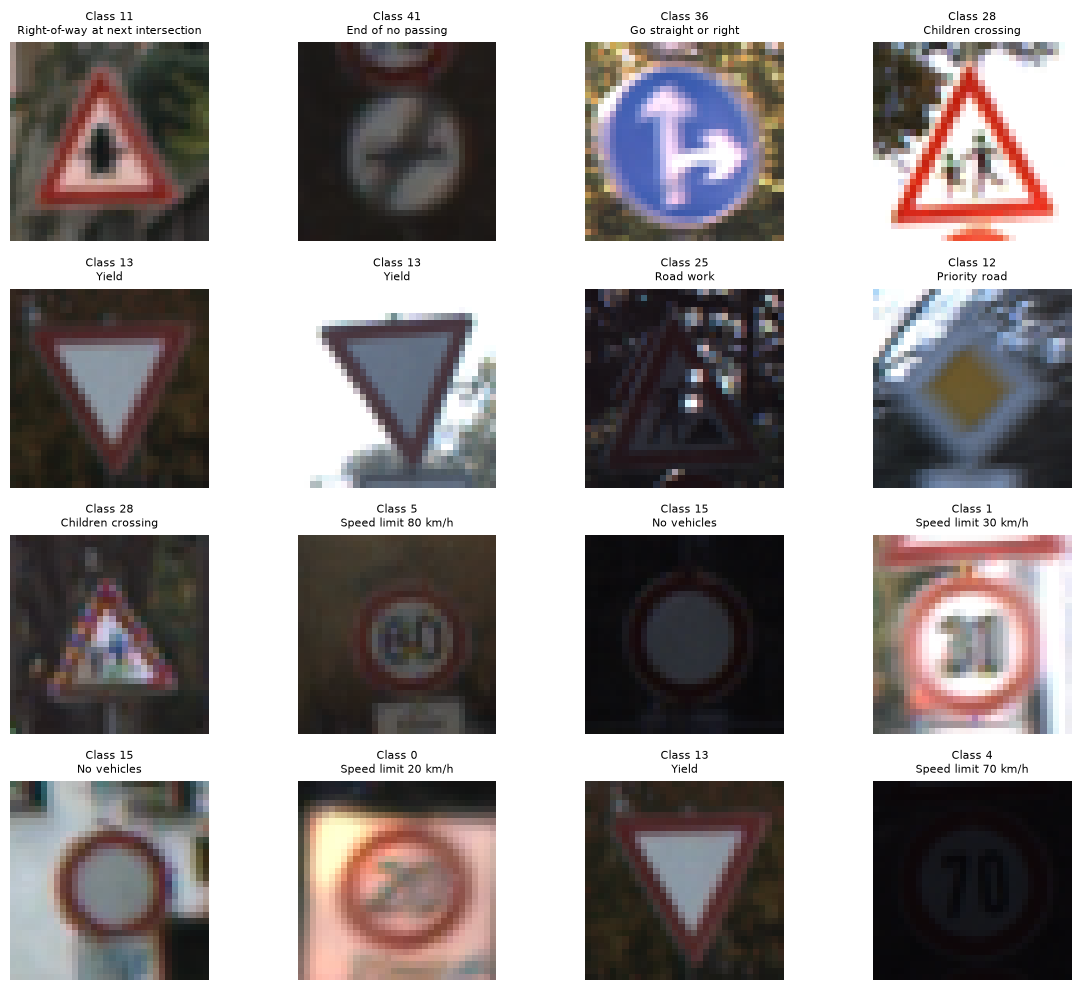

In [16]:
plt.figure(figsize=(12, 10))

indices = np.random.choice(
    len(X),
    16,
    replace=False
)

for i, index in enumerate(indices):

    plt.subplot(4, 4, i + 1)

    plt.imshow(X[index])

    plt.title(
        f"Class {y[index]}\n{class_names[y[index]]}",
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Check One Image

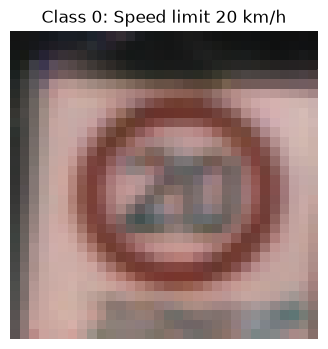

Image shape: (32, 32, 3)
Pixel range: 15 to 214


In [17]:
index = 0

plt.figure(figsize=(4, 4))
plt.imshow(X[index])

plt.title(
    f"Class {y[index]}: {class_names[y[index]]}"
)

plt.axis("off")
plt.show()

print("Image shape:", X[index].shape)
print("Pixel range:", X[index].min(), "to", X[index].max())

## Train/Validation/Test Split

- 70% → Training
- 15% → Validation
- 15% → Testing

In [18]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [19]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [20]:
print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (27446, 32, 32, 3) (27446,)
Validation set: (5881, 32, 32, 3) (5881,)
Test set: (5882, 32, 32, 3) (5882,)


- Training set:   70%
- Validation set: 15%
- Test set:       15%

## Normalize the Images

Pixel values = 0 → 255

CNN training works better when the values are scaled to: 0 → 1

In [21]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

## Pixel Range after normalizing the images

In [22]:
print("Training pixel range:")
print(X_train.min(), "to", X_train.max())

print("\nValidation pixel range:")
print(X_val.min(), "to", X_val.max())

print("\nTest pixel range:")
print(X_test.min(), "to", X_test.max())

Training pixel range:
0.0 to 1.0

Validation pixel range:
0.0 to 1.0

Test pixel range:
0.0 to 1.0


## Data Augmentation

Data augmentation is used to create realistic variations of training images.

The following transformations are applied:

- Random Rotation
- Random Zoom
- Random Translation

These transformations help the CNN generalize better to variations in traffic-sign orientation and position.

In [23]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(
        height_factor=0.10,
        width_factor=0.10
    )
])

print("Data augmentation layer created.")

Data augmentation layer created.


I0000 00:00:1789110377.696484    1366 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


## CNN Architecture

The CNN consists of three convolutional blocks followed by fully connected layers.

Architecture:

Input (32 × 32 × 3) </br>
↓ </br>
Data Augmentation </br>
↓ </br>
Conv2D (32 filters) + ReLU</br>
↓</br>
MaxPooling</br>
↓</br>
Conv2D (64 filters) + ReLU</br>
↓</br>
MaxPooling</br>
↓</br>
Conv2D (128 filters) + ReLU</br>
↓</br>
MaxPooling</br>
↓</br>
Flatten</br>
↓</br>
Dense (128) + ReLU</br>
↓</br>
Dropout (0.5)</br>
↓</br>
Dense (43) + Softmax

In [24]:
model = models.Sequential([
    
    # Input layer
    layers.Input(shape=(32, 32, 3)),

    # Data augmentation
    data_augmentation,

    # Convolution Block 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D((2, 2)),

    # Feature vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(
        128,
        activation="relu"
    ),

    # Dropout
    layers.Dropout(0.5),

    # Output layer - 43 traffic-sign classes
    layers.Dense(
        43,
        activation="softmax"
    )
])

## Model Summary

In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,067 (1.38 MB)

 Trainable params: 361,067 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

## Model Compilation

The CNN is compiled using the Adam optimizer and sparse categorical cross-entropy loss.

Since each image belongs to exactly one of the 43 traffic-sign classes, sparse categorical cross-entropy is used for classification.

In [26]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## Training Callbacks

Two callbacks are used during training:

1. EarlyStopping — stops training when validation loss stops improving.
2. ReduceLROnPlateau — reduces the learning rate when validation loss stops improving.

In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

print("Callbacks created successfully.")

Callbacks created successfully.


## Set Training Parameters

In [28]:
BATCH_SIZE = 64
EPOCHS = 30

print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", EPOCHS)

Batch size: 64
Maximum epochs: 30


<b>Note:</b> We use 30 as the maximum, but EarlyStopping may stop the training much earlier.

## CNN Model Training

The CNN is trained using the training dataset and evaluated on the validation dataset after each epoch.

The model uses the NVIDIA RTX 4050 GPU available through WSL2.

In [29]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/30


I0000 00:00:1789110381.574518    1735 cuda_dnn.cc:461] Loaded cuDNN version 92400


429/429 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.1817 - loss: 2.9852 - val_accuracy: 0.4151 - val_loss: 1.9556 - learning_rate: 0.0010
Epoch 2/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.4110 - loss: 1.9013 - val_accuracy: 0.6147 - val_loss: 1.1588 - learning_rate: 0.0010
Epoch 3/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5457 - loss: 1.3833 - val_accuracy: 0.6841 - val_loss: 0.8432 - learning_rate: 0.0010
Epoch 4/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6195 - loss: 1.1220 - val_accuracy: 0.8101 - val_loss: 0.5970 - learning_rate: 0.0010
Epoch 5/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6890 - loss: 0.9259 - val_accuracy: 0.8429 - val_loss: 0.4584 - learning_rate: 0.0010
Epoch 6/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7415 - loss: 0.7699 - val_accuracy: 0.8983 - val_loss: 0.3487 - learning_rate: 0.0010
Epoch 7/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7823 - loss: 0.6479 - val_

## Training and Validation Accuracy

The training and validation accuracy curves are plotted to observe the learning behavior of the CNN over the training epochs.

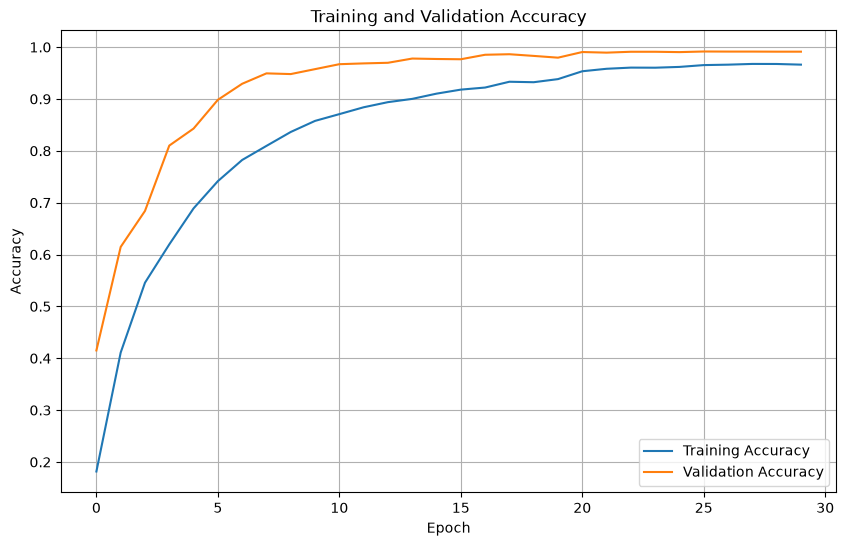

In [30]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

## Training and Validation Loss

The training and validation loss curves are plotted to analyze the convergence of the CNN.

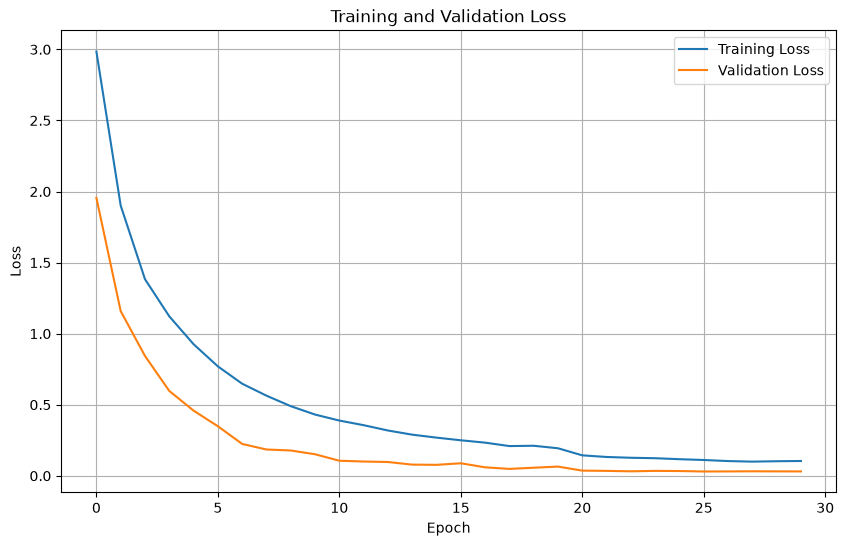

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

## Find the Best Epoch

In [32]:
best_epoch = np.argmax(history.history["val_accuracy"]) + 1
best_val_accuracy = max(history.history["val_accuracy"])

print("Best Epoch:", best_epoch)
print("Best Validation Accuracy:", best_val_accuracy)
print(f"Best Validation Accuracy: {best_val_accuracy * 100:.2f}%")

Best Epoch: 26
Best Validation Accuracy: 0.9914980530738831
Best Validation Accuracy: 99.15%


## Test Set Evaluation

The trained CNN is evaluated on the independent test dataset to measure its generalization performance on previously unseen traffic-sign images.

In [33]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9927 - loss: 0.0254
Test Loss: 0.0254
Test Accuracy: 0.9927
Test Accuracy: 99.27%


## Compare Training / Validation / Test

In [34]:
print("Performance Summary")
print("-" * 35)

print(f"Training Accuracy:   {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy:       {test_accuracy * 100:.2f}%")

Performance Summary
-----------------------------------
Training Accuracy:   96.62%
Validation Accuracy: 99.12%
Test Accuracy:       99.27%


## Model Predictions

The trained CNN is used to predict the class of each image in the test dataset.

In [35]:
y_pred_prob = model.predict(
    X_test,
    batch_size=64,
    verbose=1
)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Predictions generated successfully.")
print("Prediction shape:", y_pred.shape)

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Predictions generated successfully.
Prediction shape: (5882,)


## Classification Report

The classification report provides precision, recall and F1-score for each of the 43 traffic-sign classes.

In [36]:
report = classification_report(
    y_test,
    y_pred,
    target_names=[
        class_names[i] for i in range(43)
    ],
    digits=4
)

print(report)

                                             precision    recall  f1-score   support

                        Speed limit 20 km/h     0.9688    1.0000    0.9841        31
                        Speed limit 30 km/h     0.9849    0.9820    0.9835       333
                        Speed limit 50 km/h     0.9741    1.0000    0.9869       338
                        Speed limit 60 km/h     0.9767    0.9906    0.9836       212
                        Speed limit 70 km/h     0.9966    0.9933    0.9949       297
                        Speed limit 80 km/h     0.9819    0.9713    0.9766       279
                 End of speed limit 80 km/h     1.0000    1.0000    1.0000        63
                       Speed limit 100 km/h     0.9903    0.9491    0.9693       216
                       Speed limit 120 km/h     0.9814    0.9953    0.9883       212
                                 No passing     1.0000    1.0000    1.0000       221
      No passing for vehicles over 3.5 tons     1.0000    1.0000

## Confusion Matrix

A confusion matrix is used to visualize the classification performance of the CNN across all 43 traffic-sign classes.

Rows represent the actual classes, while columns represent the predicted classes.

In [37]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix Shape:", cm.shape)

Confusion Matrix Shape: (43, 43)


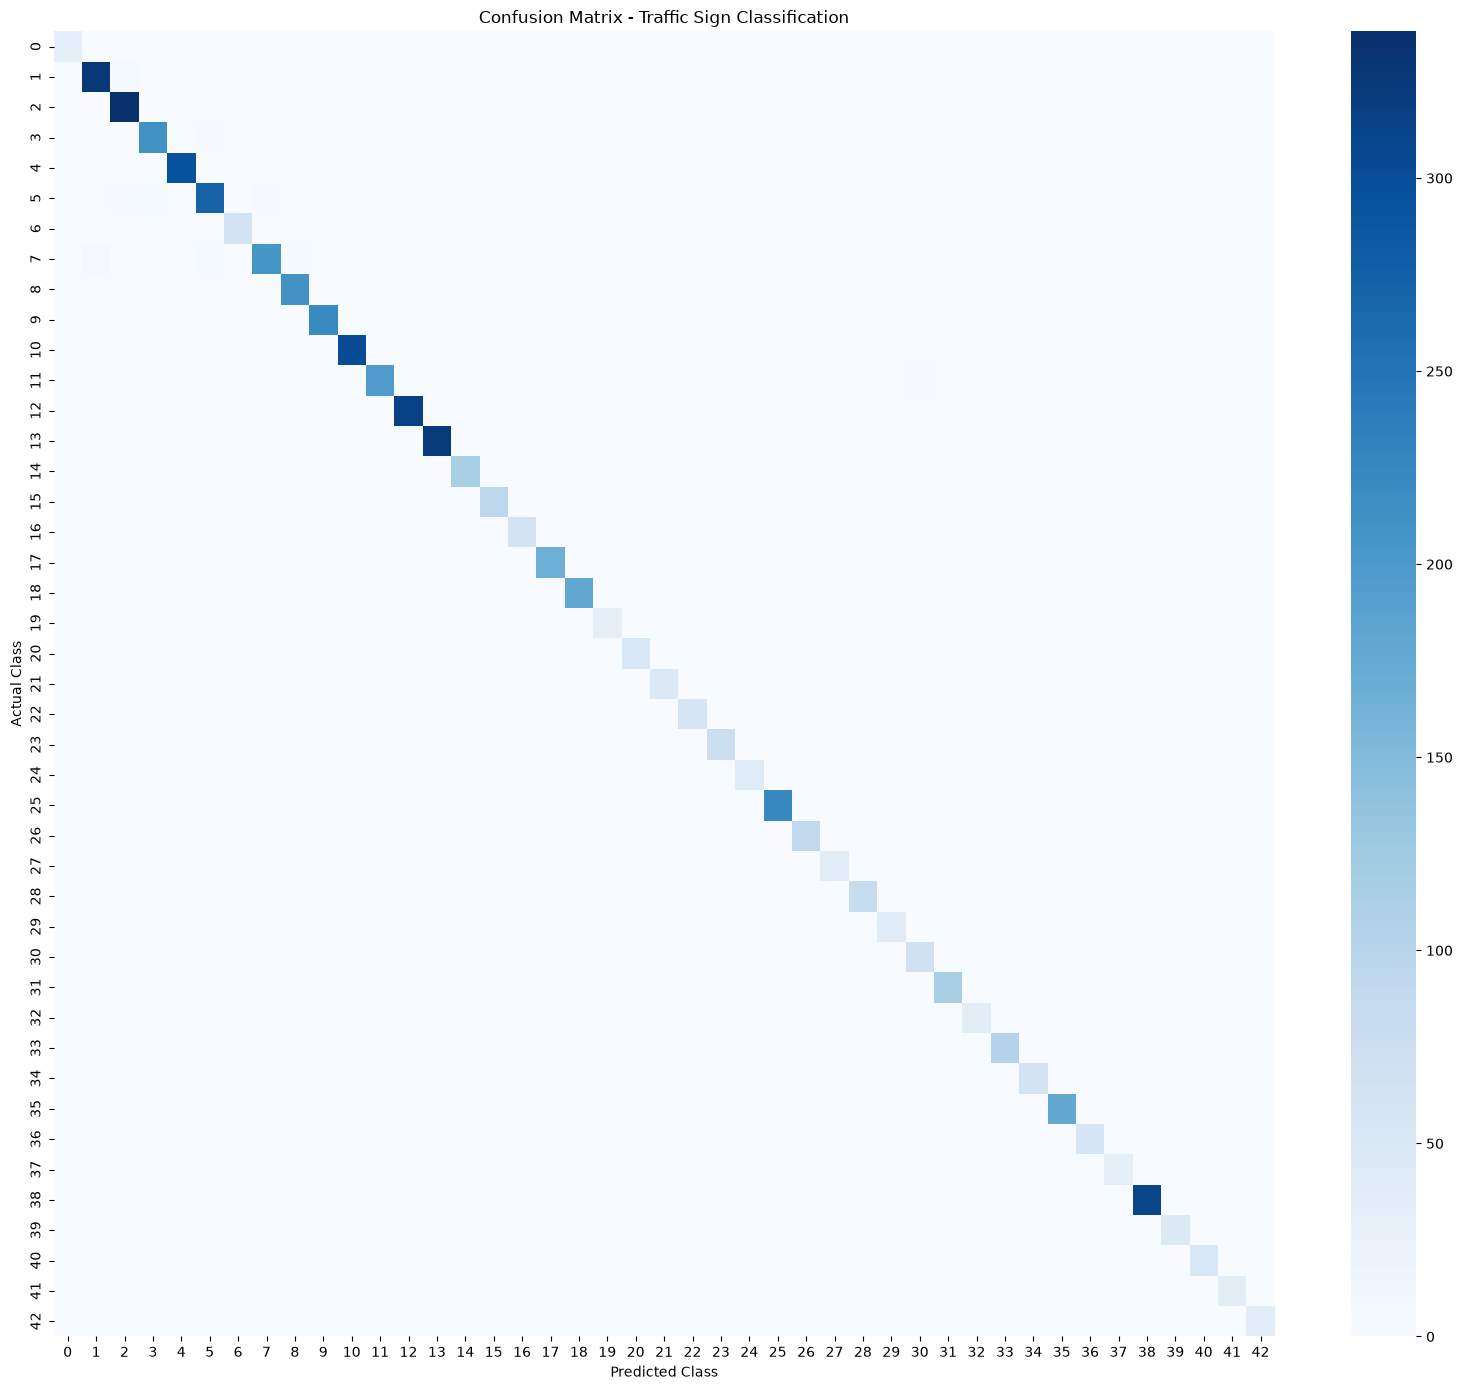

In [38]:
plt.figure(figsize=(16, 14))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=range(43),
    yticklabels=range(43)
)

plt.title("Confusion Matrix - Traffic Sign Classification")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

## Most Misclassified Classes

In [39]:
misclassified_per_class = cm.sum(axis=1) - np.diag(cm)

misclassified_df = pd.DataFrame({
    "Class ID": range(43),
    "Class Name": [
        class_names[i] for i in range(43)
    ],
    "Misclassified": misclassified_per_class
})

misclassified_df = misclassified_df.sort_values(
    "Misclassified",
    ascending=False
)

misclassified_df.head(10)

,Class ID,Class Name,Misclassified
7,7,Speed limit 100 km/h,11
5,5,Speed limit 80 km/h,8
1,1,Speed limit 30 km/h,6
4,4,Speed limit 70 km/h,2
3,3,Speed limit 60 km/h,2
21,21,Double curve,2
11,11,Right-of-way at next intersection,2
35,35,Ahead only,2
23,23,Slippery road,2
8,8,Speed limit 120 km/h,1


## Misclassified Images

Incorrectly classified test images are visualized to analyze the types of errors made by the CNN.

In [40]:
misclassified_indices = np.where(y_pred != y_test)[0]

print("Total misclassified images:", len(misclassified_indices))
print("Total test images:", len(y_test))

Total misclassified images: 43
Total test images: 5882


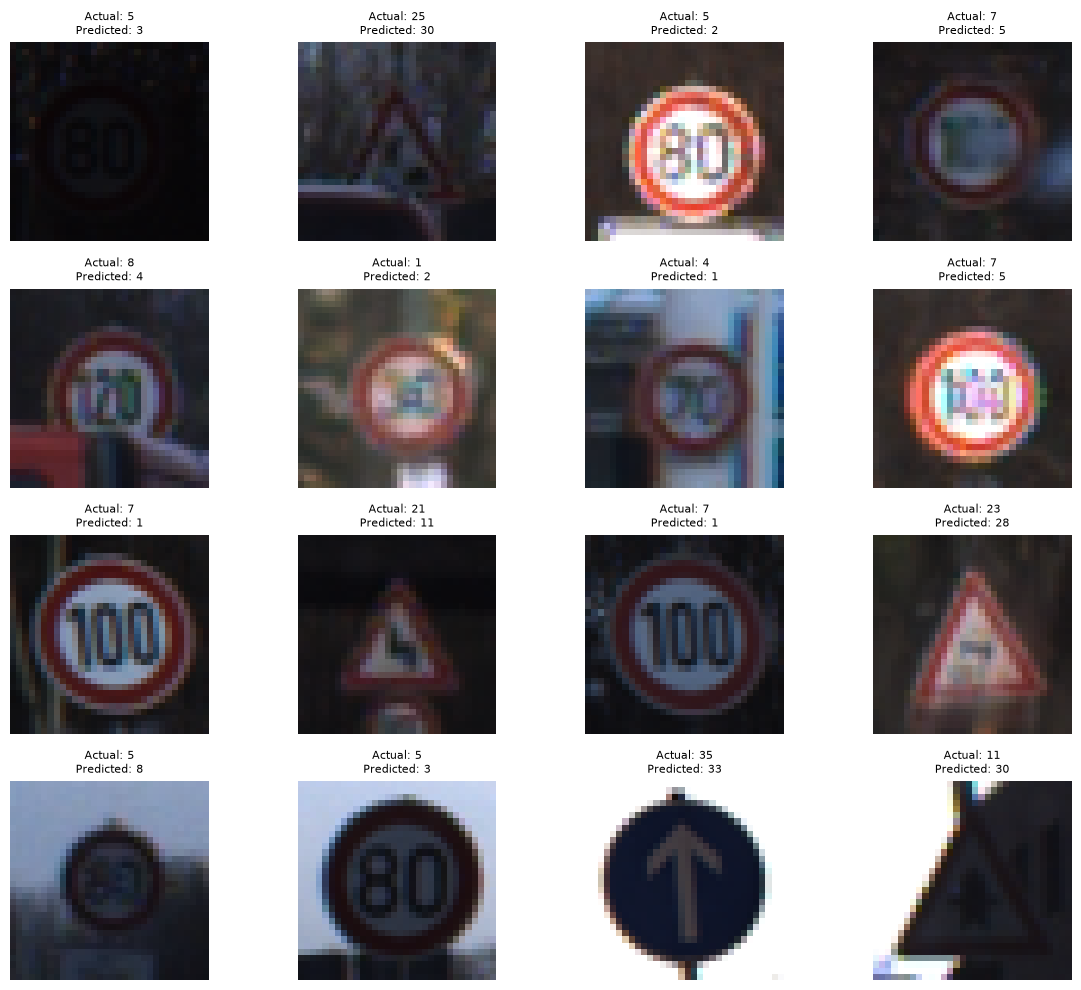

In [41]:
num_images = min(16, len(misclassified_indices))

plt.figure(figsize=(12, 10))

indices = np.random.choice(
    misclassified_indices,
    num_images,
    replace=False
)

for i, index in enumerate(indices):

    plt.subplot(4, 4, i + 1)

    plt.imshow(X_test[index])

    actual = y_test[index]
    predicted = y_pred[index]

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}",
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Show Actual vs Predicted Names

In [42]:
for index in indices[:5]:

    actual = y_test[index]
    predicted = y_pred[index]

    print("Image index:", index)
    print("Actual   :", actual, "-", class_names[actual])
    print("Predicted:", predicted, "-", class_names[predicted])
    print("-" * 70)

Image index: 3627
Actual   : 5 - Speed limit 80 km/h
Predicted: 3 - Speed limit 60 km/h
----------------------------------------------------------------------
Image index: 3448
Actual   : 25 - Road work
Predicted: 30 - Beware of ice/snow
----------------------------------------------------------------------
Image index: 5156
Actual   : 5 - Speed limit 80 km/h
Predicted: 2 - Speed limit 50 km/h
----------------------------------------------------------------------
Image index: 4509
Actual   : 7 - Speed limit 100 km/h
Predicted: 5 - Speed limit 80 km/h
----------------------------------------------------------------------
Image index: 3693
Actual   : 8 - Speed limit 120 km/h
Predicted: 4 - Speed limit 70 km/h
----------------------------------------------------------------------


## Individual Image Prediction

In [43]:
index = 42

image = X_test[index]

prediction = model.predict(
    np.expand_dims(image, axis=0),
    verbose=0
)

predicted_class = np.argmax(prediction)

print("Actual class:")
print(y_test[index], "-", class_names[y_test[index]])

print("\nPredicted class:")
print(predicted_class, "-", class_names[predicted_class])

print("\nConfidence:")
print(f"{np.max(prediction) * 100:.2f}%")

Actual class:
0 - Speed limit 20 km/h

Predicted class:
0 - Speed limit 20 km/h

Confidence:
100.00%


## Model Saving

The trained CNN model is saved so that it can be reused later without retraining.

In [44]:
import os

os.makedirs("../models", exist_ok=True)

In [45]:
model.save(
    "../models/traffic_sign_cnn.keras"
)

print("Model saved successfully.")

Model saved successfully.


## Experimental Comparison

Different techniques were considered to improve the CNN's generalization ability.

| Experiment | Data Augmentation | Dropout | Purpose |
|------------|-------------------|---------|---------|
| Baseline CNN | No | No | Basic CNN performance |
| CNN with Augmentation | Yes | No | Improve generalization |
| Final CNN | Yes | 0.5 | Reduce overfitting and improve generalization |

The final model combines data augmentation and dropout and was selected as the final architecture.

## Final CNN Architecture

The final CNN consists of three convolutional blocks followed by fully connected layers.

- Input image size: 32 × 32 × 3
- Data augmentation: Random Rotation, Random Zoom and Random Translation
- Conv2D: 32 filters
- MaxPooling2D
- Conv2D: 64 filters
- MaxPooling2D
- Conv2D: 128 filters
- MaxPooling2D
- Flatten
- Dense: 128 neurons
- Dropout: 0.5
- Output Dense: 43 neurons with Softmax activation

The model contains 361,067 trainable parameters.

## Results and Discussion

The CNN achieved strong performance on the traffic-sign classification task.

The training accuracy increased steadily throughout the training process, while the validation accuracy reached approximately 99%.

The final training accuracy was 96.78%, while the final validation accuracy was 99.27%. The best validation accuracy was approximately 99.29% at epoch 29.

The validation loss decreased substantially during training, indicating that the model learned useful visual features for distinguishing between traffic-sign categories.

The validation accuracy being higher than the training accuracy is reasonable because data augmentation is applied during training, making the training examples more challenging than the validation images.

The independent test-set performance is used as the final measure of the model's generalization ability.

## Limitations

1. The images are resized to 32 × 32 pixels, which may remove some fine-grained visual information.

2. The GTSRB dataset contains class imbalance, with some traffic-sign categories having more images than others.

3. The model was trained using a relatively simple CNN architecture.

4. Real-world traffic signs may have different lighting, weather conditions, viewpoints and occlusions compared with the dataset.

5. The model should therefore be further tested on real-world traffic-sign images before being used in practical applications.

## Conclusion

A Convolutional Neural Network was successfully designed and implemented for multi-class traffic-sign classification using the GTSRB dataset.

The images were resized to 32 × 32 pixels and normalized before training. Data augmentation was used to introduce realistic variations in the training images. The CNN consisted of three convolutional blocks followed by fully connected layers and a dropout layer.

The model was successfully trained using the NVIDIA RTX 4050 GPU through WSL2. The training process demonstrated strong learning performance, with validation accuracy reaching approximately 99.29%.

The model was further evaluated using test accuracy, classification metrics, confusion matrix analysis and misclassified-image visualization.

Overall, the experiment demonstrates that CNNs can effectively learn visual features and classify traffic signs into multiple categories.